# Shipment loss prediction (RNA)

Objective: train a neural network that predicts `is_lost` for a shipment **at
creation time, before dispatch**. This constrains the whole notebook: any
column that is only known once the shipment is in transit or resolved (a
tracking status, a loss cause, a cashout amount) is leakage and must be
excluded, even if it correlates strongly with the label. The exploration
section below exists to find and demonstrate exactly which columns fall into
that trap in this dataset, before they ever reach the model -- including a
column that looks like plain geography (`LG_REGION`) but turns out to encode
the label through an inconsistent taxonomy (section 2), and a general
"purity audit" check (section 3) built to catch that class of problem in any
categorical feature, not just the one found here.

## 1. Setup

Constants are defined once at the top so the rest of the notebook (and a
future inference script) reads them from a single place. `TIME_LIMIT` is
read from the `RNA_TIME_LIMIT` environment variable so the same notebook can
run as a quick smoke test (headless, `nbconvert --execute`) or as a longer
real training run without editing code.

In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit

DATA_PATH = "../dataset.parquet"
LABEL = "is_lost"
GROUP = "SHIPMENT_ID"
RANDOM_STATE = 42
TIME_LIMIT = int(os.environ.get("RNA_TIME_LIMIT", 600))
MODEL_DIR = "../AutogluonModels/rna_shipment_loss"

# Palette: blue/red as a diverging pair (not-lost / lost read as opposites),
# one consistent hue per role across every figure in the notebook.
COLOR_NOT_LOST = "#2a78d6"
COLOR_LOST = "#e34948"
COLOR_SEQUENTIAL = "#2a78d6"
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "riskship_diverging", ["#e34948", "#f0efec", "#2a78d6"]
)

sns.set_theme(style="whitegrid", rc={"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb"})

## 2. Exploration of the raw data

Before touching any preprocessing decision, look at the raw dataset: its
shape, column types, missingness, label balance, and the evidence behind the
cleaning decisions applied in section 3 (label leakage, the `DATEPARAMETER`
vs `date_status_0` inconsistency, the temporal sampling bias, the
missingness artifacts, and the item-level row granularity).

In [2]:
raw = pd.read_parquet(DATA_PATH)
# Parquet's date32 type round-trips as plain python `date` objects (object
# dtype) rather than datetime64, so date arithmetic needs an explicit cast.
raw["DATEPARAMETER"] = pd.to_datetime(raw["DATEPARAMETER"])
print(f"shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.dtypes.value_counts()

shape: 262,317 rows x 58 columns


object            36
datetime64[us]    11
float64            6
int64              3
bool               1
datetime64[ns]     1
Name: count, dtype: int64

In [3]:
null_rate = raw.isna().mean().sort_values(ascending=False)
null_rate[null_rate > 0].to_frame("null_rate")

,null_rate
CANT_BULTOS,1.000000
FUE_AVION,0.947098
TIPO_BULKY,0.904585
status_1,0.768898
status_0,0.761285
L1_CAUSA_BPP,0.757225
F_CLASIFICATION_STD,0.757225
F_CLASIFICATION,0.757225
L2_CAUSA_BPP,0.757225
CAUSA_BPP,0.757225


In [4]:
label_counts = raw[LABEL].value_counts().sort_index()
label_rate = raw[LABEL].mean()
print(label_counts)
print(f"positive rate: {label_rate:.3f}")

is_lost
0    198633
1     63684
Name: count, dtype: int64
positive rate: 0.243


### Evidence: pure label leakage (fact 2)

A handful of columns are only populated once a shipment has already been
classified as lost. If a column is non-null for 100% of lost rows and 0% of
non-lost rows, it cannot be legitimate input at creation time -- it is a
restatement of the label.

In [5]:
LEAKAGE_COLUMNS = [
    "CAUSA_BPP",
    "L1_CAUSA_BPP",
    "L2_CAUSA_BPP",
    "DATE_BPP",
    "BPP_CASHOUT_USD",
    "CLASSIFICATION_LM",
    "SUBSTATUS_CLASIFICATION",
    "F_CLASIFICATION",
    "F_CLASIFICATION_STD",
]

leakage_evidence = raw.groupby(LABEL)[LEAKAGE_COLUMNS].apply(lambda g: g.notna().mean())
leakage_evidence

,CAUSA_BPP,L1_CAUSA_BPP,L2_CAUSA_BPP,DATE_BPP,BPP_CASHOUT_USD,CLASSIFICATION_LM,SUBSTATUS_CLASIFICATION,F_CLASIFICATION,F_CLASIFICATION_STD
is_lost,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Evidence: `DATEPARAMETER` vs `date_status_0` (fact 4)

`DATEPARAMETER` looks like a neutral date column, but comparing it to
`date_status_0` (the first status timestamp, i.e. shipment start) shows it
silently encodes the label: identical to `date_status_0` for non-lost rows,
and several days later for lost rows. `date_status_0` is the consistent
shipment-start timestamp; `DATEPARAMETER` must be dropped.

In [6]:
date_gap_days = (raw["DATEPARAMETER"] - raw["date_status_0"].dt.normalize()).dt.days
gap_by_label = date_gap_days.groupby(raw[LABEL]).agg(["mean", "median", "max"])
gap_by_label

,mean,median,max
is_lost,,,
0,0.00000,0.0,0.0
1,8.79741,7.0,95.0


### Evidence: temporal sampling bias (fact 5)

Grouping by month of `DATEPARAMETER`, the lost rate swings wildly and drops
to exactly zero for the most recent months. This is not a real seasonal
effect: it means the "lost" label has not matured yet for recent shipments
(a shipment is only marked lost some time after creation), so recent months
falsely look safe. Any month where only one class is present must be
excluded from training, or the model would learn the extraction artifact
instead of real risk.

In [7]:
month_of_dateparameter = raw["DATEPARAMETER"].dt.to_period("M")
lost_rate_by_month = raw.groupby(month_of_dateparameter)[LABEL].agg(["mean", "count"])
lost_rate_by_month

,mean,count
DATEPARAMETER,,
2025-09,0.098140,13226
2025-10,0.356325,19210
2025-11,0.391343,28139
2025-12,0.498999,39970
2026-01,0.381887,24104
2026-02,0.322367,18997
2026-03,0.365093,22849
2026-04,0.058131,15706
2026-05,0.000000,17699


### Evidence: missingness artifacts (fact 6)

Rows missing core numeric fields (weight, dimensions, value, item count) or
missing `date_status_0` are almost all lost -- again an artifact of how the
two classes were extracted, not a real relationship between "shipment has no
weight recorded" and "shipment gets lost". These rows are dropped rather
than imputed.

In [8]:
MISSINGNESS_ARTIFACT_COLUMNS = ["PESO_TOTAL_KG", "DIM_MAX_CM", "VALOR_TOTAL_USD", "CANTIDAD_ITEMS"]

for column in MISSINGNESS_ARTIFACT_COLUMNS + ["date_status_0"]:
    is_null = raw[column].isna()
    print(f"{column}: {is_null.mean():.4%} null, lost rate when null = {raw.loc[is_null, LABEL].mean():.3f}")

PESO_TOTAL_KG: 0.4506% null, lost rate when null = 0.998
DIM_MAX_CM: 0.4506% null, lost rate when null = 0.998
VALOR_TOTAL_USD: 0.4498% null, lost rate when null = 1.000
CANTIDAD_ITEMS: 0.4498% null, lost rate when null = 1.000
date_status_0: 0.4060% null, lost rate when null = 1.000


### Evidence: `LG_REGION` uses two taxonomies

`LG_REGION` looks like a legitimate at-creation feature (a shipment's
facility and region are known when it is created), but its per-value lost
rate is suspiciously bimodal. The reason: the same facility is exported
under different region names depending on the row's class, so the region
name itself ends up encoding the label. `SHP_LG_FACILITY_ID` does not have
this problem and is kept as the geographic feature instead.

In [9]:
region_stats = raw.groupby("LG_REGION", observed=True)[LABEL].agg(["mean", "count"])
pure_regions = region_stats[(region_stats["mean"] == 0) | (region_stats["mean"] == 1)]
pure_row_share = pure_regions["count"].sum() / len(raw)
print(f"LG_REGION values: {len(region_stats)}, pure (exactly 0% or 100% lost): {len(pure_regions)}")
print(f"share of rows in a pure region value: {pure_row_share:.1%}")
print("pure at 0% lost:", sorted(pure_regions.loc[pure_regions['mean'] == 0].index.tolist()))
print("pure at 100% lost:", sorted(pure_regions.loc[pure_regions['mean'] == 1].index.tolist()))

LG_REGION values: 25, pure (exactly 0% or 100% lost): 17
share of rows in a pure region value: 52.6%
pure at 0% lost: ['Central', 'Cluster Puebla', 'Epicentro', 'Golfo', 'Istmo', 'Jalisco', 'Levante', 'MS Sureste', 'Norcentral', 'Pacifico', 'Poniente']
pure at 100% lost: ['Bajio', 'Istmo-Golfo', 'Metro Central', 'Metro Megas', 'Metro Poniente', 'Occidente']


In [10]:
facility_region_counts = raw.groupby("SHP_LG_FACILITY_ID", observed=True)["LG_REGION"].nunique()
multi_region_facilities = facility_region_counts[facility_region_counts > 1]
print(f"facilities: {facility_region_counts.shape[0]}, mapped to more than one region name: {len(multi_region_facilities)}")

facility_region_breakdown = (
    raw[raw["SHP_LG_FACILITY_ID"].isin(multi_region_facilities.index)]
    .groupby(["SHP_LG_FACILITY_ID", "LG_REGION"], observed=True)[LABEL]
    .agg(["mean", "count"])
    .rename(columns={"mean": "lost_rate"})
)
top_multi_region_facilities = (
    facility_region_breakdown.groupby(level=0)["count"].sum().sort_values(ascending=False).head(5).index
)
facility_region_breakdown.loc[top_multi_region_facilities]

facilities: 104, mapped to more than one region name: 53


lost_rate  count
SHP_LG_FACILITY_ID LG_REGION                      
SMX11              Metro Megas          1.0   3682
                   Metro Norte          0.0   3944
SGD2               Centro               1.0   2546
                   Jalisco              0.0   5006
SQR1               Bajio                1.0   2922
                   Epicentro            0.0   4273
SMX9               Centro               0.0   5339
                   Metro Central        1.0   1683
SLE1               Bajio                1.0   2974
                   Epicentro            0.0   3830

### Evidence: item-level granularity (fact 9)

A row is one item of a shipment, not one shipment: some `SHIPMENT_ID`s
appear multiple times. The label never disagrees within a shipment, so this
is safe to keep at item granularity, but every split must group by
`SHIPMENT_ID` or the same shipment could leak across train/validation/test.

In [11]:
shipments_per_row_count = raw.groupby(GROUP).size()
multi_row_shipments = shipments_per_row_count[shipments_per_row_count > 1]
print(f"shipments with more than one row: {len(multi_row_shipments):,}")
print(f"rows belonging to a multi-row shipment: {multi_row_shipments.sum():,}")

label_conflicts = raw.groupby(GROUP)[LABEL].nunique()
print(f"shipments with conflicting labels across rows: {(label_conflicts > 1).sum()}")

shipments with more than one row: 8,837
rows belonging to a multi-row shipment: 25,077


shipments with conflicting labels across rows: 0


## 3. Cleaning and preprocessing

`preprocess` is one function so the same logic can move into an inference
script later without duplicating decisions. It only does what AutoGluon
cannot do for us: remove leakage, remove sampling artifacts, and fix
granularity. It does **not** scale, impute, or one-hot encode -- AutoGluon's
`TabularPredictor` handles missing values, encoding, and scaling internally
for both the tree and the neural-network models it can train, so manual
work here would only duplicate or fight that logic.

Column lists below double as documentation: every raw column is accounted
for as either a kept feature, the label, the group key, or an explicitly
named reason to drop it -- including `TAXONOMY_ARTIFACT_COLUMNS`, added
after the `LG_REGION` finding in section 2.

In [12]:
TIMELINE_COLUMNS = (
    [f"status_{i}" for i in range(11)] + [f"date_status_{i}" for i in range(1, 11)]
)
DATE_LEAK_COLUMNS = ["DATEPARAMETER"]
CONSTANT_COLUMNS = ["PAIS", "TOTALGMV", "CANT_BULTOS"]
REDUNDANT_COLUMNS = ["LG_FACILITY_NAME", "ORD_CATEGORY_ID_L1"]
IDENTIFIER_COLUMNS = ["SHP_SHIPMENT_ID", "ITE_ITEM_ID", "ITE_ITEM_DESC"]
ROUTE_COLUMNS = ["FUE_AVION"]
PROVENANCE_COLUMNS = ["source_file", "batch_num"]
# LG_REGION is exported under different names for the same facility
# depending on the row's class (see section 2 evidence), so it encodes the
# label rather than real geography; SHP_LG_FACILITY_ID carries that signal
# safely instead.
TAXONOMY_ARTIFACT_COLUMNS = ["LG_REGION"]
DATE_COLUMN = "date_status_0"

CATEGORICAL_FEATURES = [
    "PICKING_TYPE",
    "SHP_LG_FACILITY_ID",
    "DOM_DOMAIN_ID",
    "ORD_CATEGORY_NAME_L1",
    "BRAND_NAME",
    "TIPO_BULKY",
]
NUMERIC_FEATURES = [
    "PESO_TOTAL_KG",
    "DIM_MAX_CM",
    "VALOR_TOTAL_USD",
    "CANTIDAD_ITEMS",
    "RATIO_SVC_MES_ANTERIOR",
    "ES_BULKY",
]
DERIVED_FEATURES = ["day_of_week"]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES + DERIVED_FEATURES
print(f"feature count: {len(FEATURE_COLUMNS)}")

DROPPED_COLUMNS = (
    LEAKAGE_COLUMNS
    + TIMELINE_COLUMNS
    + DATE_LEAK_COLUMNS
    + CONSTANT_COLUMNS
    + REDUNDANT_COLUMNS
    + IDENTIFIER_COLUMNS
    + ROUTE_COLUMNS
    + PROVENANCE_COLUMNS
    + TAXONOMY_ARTIFACT_COLUMNS
)

# Every raw column must be accounted for: a kept feature, the label, the
# group key, the date used to derive day_of_week, or a named drop reason.
accounted_for = set(CATEGORICAL_FEATURES + NUMERIC_FEATURES) | set(DROPPED_COLUMNS) | {LABEL, GROUP, DATE_COLUMN}
assert accounted_for == set(raw.columns), sorted(set(raw.columns) - accounted_for)

feature count: 13


In [13]:
def preprocess(raw: pd.DataFrame) -> pd.DataFrame:
    """Turn the raw export into a model-ready frame: features + LABEL + GROUP.

    Leakage columns, the post-creation timeline, and export bookkeeping are
    dropped outright. Row filters remove rows that only exist because of how
    the two label classes were extracted (missingness artifacts, months
    where the label has not matured yet), not because they are invalid
    shipments.
    """
    frame = raw.copy()
    print(f"rows before any filter: {len(frame):,}")

    # Missingness artifact rows (fact 6): these nulls mark rows pulled by the
    # extraction, not real missing measurements.
    artifact_null = frame[MISSINGNESS_ARTIFACT_COLUMNS + [DATE_COLUMN]].isna().any(axis=1)
    frame = frame.loc[~artifact_null]
    print(f"rows after dropping missingness-artifact rows: {len(frame):,}")

    # Label maturity window (fact 5): keep only months of date_status_0 where
    # both classes are observed, computed from the data rather than hardcoded.
    month = frame[DATE_COLUMN].dt.to_period("M")
    classes_per_month = frame.groupby(month)[LABEL].nunique()
    valid_months = classes_per_month[classes_per_month == 2].index
    frame = frame.loc[month.isin(valid_months)]
    print(f"valid months (both classes present): {[str(m) for m in valid_months]}")
    print(f"rows after restricting to months with both classes: {len(frame):,}")

    # TIPO_BULKY null means "not bulky", not missing information.
    frame["TIPO_BULKY"] = frame["TIPO_BULKY"].fillna("NONE")

    # Only date-derived feature allowed: day of week (no absolute date/time,
    # see fact 5 -- absolute dates would just re-encode the sampling bias).
    frame["day_of_week"] = pd.Categorical(
        frame[DATE_COLUMN].dt.day_name(),
        categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
        ordered=True,
    )

    # ID-like categoricals must stay string/category, never numeric.
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("category")

    return frame[FEATURE_COLUMNS + [LABEL, GROUP]]


clean = preprocess(raw)
clean.shape

rows before any filter: 262,317
rows after dropping missingness-artifact rows: 260,104


valid months (both classes present): ['2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
rows after restricting to months with both classes: 179,990


(179990, 15)

### Purity audit: catching taxonomy leaks like `LG_REGION`

`LG_REGION` was only caught by manually noticing a suspiciously bimodal lost
rate. This check generalizes that: for every categorical feature kept in the
final feature set, what share of its rows fall into a value whose own lost
rate is extreme (<=2% or >=98%, requiring at least 200 rows so the estimate
is not just small-sample noise)? A high share is the same red flag
`LG_REGION` raised, and is worth the same investigation before trusting the
feature.

In [14]:
def categorical_purity_audit(frame, columns, label, min_rows=200, low=0.02, high=0.98):
    rows = []
    for column in columns:
        stats = frame.groupby(column, observed=True)[label].agg(["mean", "count"])
        pure = stats[(stats["count"] >= min_rows) & ((stats["mean"] <= low) | (stats["mean"] >= high))]
        rows.append({
            "feature": column,
            "values": len(stats),
            "pure_values": len(pure),
            "pure_row_share": pure["count"].sum() / len(frame),
        })
    return pd.DataFrame(rows).set_index("feature").sort_values("pure_row_share", ascending=False)


purity_audit = categorical_purity_audit(clean, CATEGORICAL_FEATURES, LABEL)
purity_audit

,values,pure_values,pure_row_share
feature,,,
DOM_DOMAIN_ID,2865,6,0.013784
SHP_LG_FACILITY_ID,96,4,0.009873
PICKING_TYPE,4,1,0.001939
ORD_CATEGORY_NAME_L1,70,0,0.000000
BRAND_NAME,28715,0,0.000000
TIPO_BULKY,3,0,0.000000


## 4. Visualization of the clean data

Figures use one consistent palette across the notebook: blue for "not lost",
red for "lost" (a diverging pair, since the two classes are meant to read as
opposites), and a single blue ramp for plain magnitude bars. Categories are
sorted by the value being shown rather than left in dataset order.

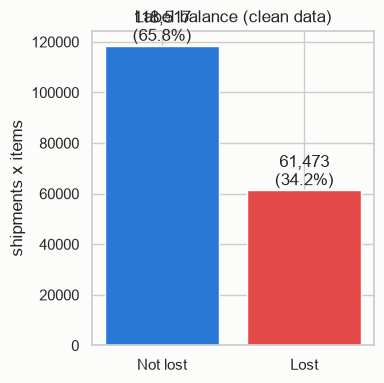

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))
counts = clean[LABEL].value_counts().sort_index()
ax.bar(["Not lost", "Lost"], counts.values, color=[COLOR_NOT_LOST, COLOR_LOST])
ax.set_title("Label balance (clean data)")
ax.set_ylabel("shipments x items")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v / counts.sum():.1%})", ha="center", va="bottom")
fig.tight_layout()

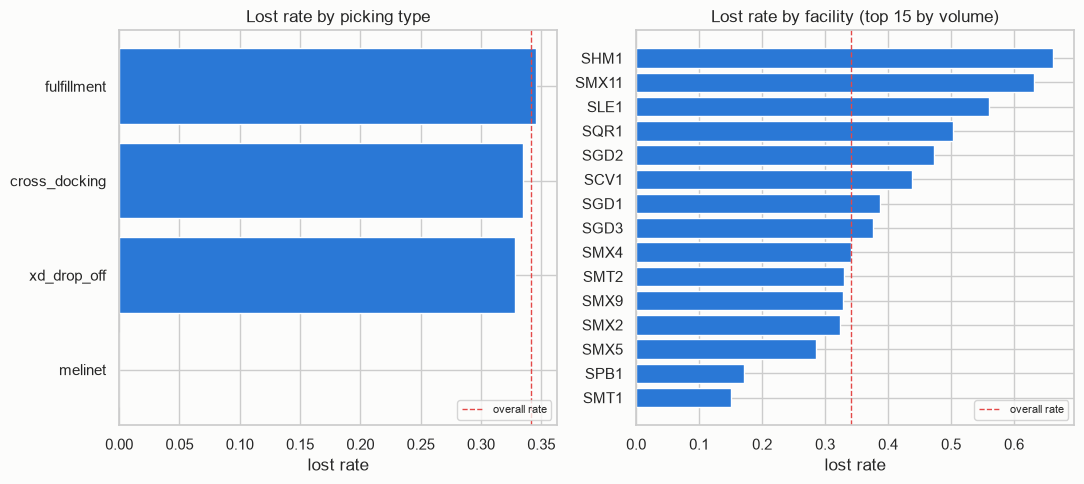

In [16]:
def lost_rate_bar(ax, series, title, top_n=None):
    rate = clean.groupby(series, observed=True)[LABEL].mean().sort_values(ascending=False)
    if top_n:
        rate = rate.head(top_n)
    ax.barh(rate.index.astype(str)[::-1], rate.values[::-1], color=COLOR_SEQUENTIAL)
    ax.set_title(title)
    ax.set_xlabel("lost rate")
    ax.axvline(clean[LABEL].mean(), color=COLOR_LOST, linestyle="--", linewidth=1, label="overall rate")
    ax.legend(loc="lower right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
lost_rate_bar(axes[0], clean["PICKING_TYPE"], "Lost rate by picking type")

top_facilities = clean["SHP_LG_FACILITY_ID"].value_counts().head(15).index
facility_rate = (
    clean[clean["SHP_LG_FACILITY_ID"].isin(top_facilities)]
    .groupby("SHP_LG_FACILITY_ID", observed=True)[LABEL]
    .mean()
    .sort_values(ascending=False)
)
axes[1].barh(facility_rate.index.astype(str)[::-1], facility_rate.values[::-1], color=COLOR_SEQUENTIAL)
axes[1].axvline(clean[LABEL].mean(), color=COLOR_LOST, linestyle="--", linewidth=1, label="overall rate")
axes[1].set_title("Lost rate by facility (top 15 by volume)")
axes[1].set_xlabel("lost rate")
axes[1].legend(loc="lower right", fontsize=8)
fig.tight_layout()

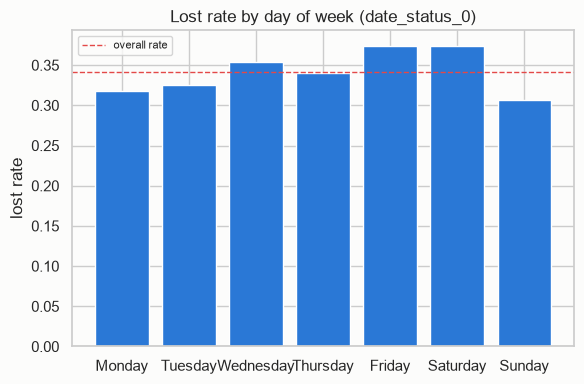

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
rate_by_dow = clean.groupby("day_of_week", observed=True)[LABEL].mean()
ax.bar(rate_by_dow.index.astype(str), rate_by_dow.values, color=COLOR_SEQUENTIAL)
ax.axhline(clean[LABEL].mean(), color=COLOR_LOST, linestyle="--", linewidth=1, label="overall rate")
ax.set_title("Lost rate by day of week (date_status_0)")
ax.set_ylabel("lost rate")
ax.legend(fontsize=8)
fig.tight_layout()

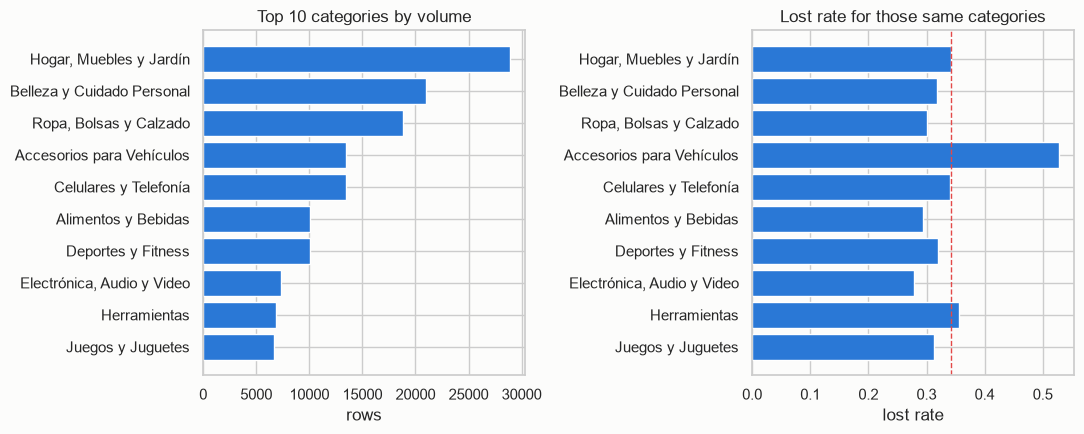

In [18]:
top_categories = clean["ORD_CATEGORY_NAME_L1"].value_counts().head(10)
rate_top_categories = clean.groupby("ORD_CATEGORY_NAME_L1", observed=True)[LABEL].mean().loc[top_categories.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(top_categories.index.astype(str)[::-1], top_categories.values[::-1], color=COLOR_SEQUENTIAL)
axes[0].set_title("Top 10 categories by volume")
axes[0].set_xlabel("rows")
axes[1].barh(rate_top_categories.index.astype(str)[::-1], rate_top_categories.values[::-1], color=COLOR_SEQUENTIAL)
axes[1].axvline(clean[LABEL].mean(), color=COLOR_LOST, linestyle="--", linewidth=1)
axes[1].set_title("Lost rate for those same categories")
axes[1].set_xlabel("lost rate")
fig.tight_layout()

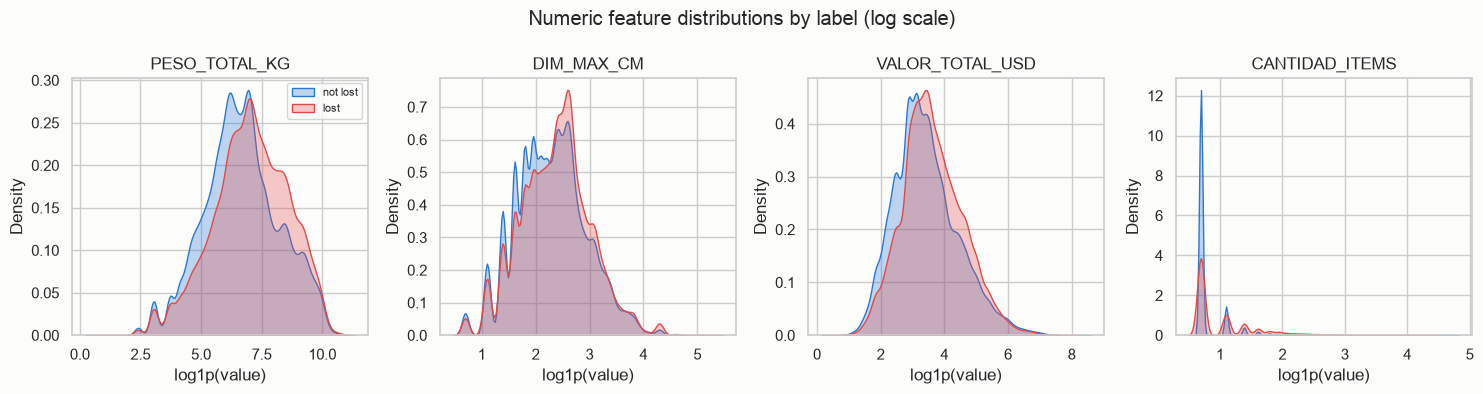

In [19]:
numeric_to_plot = ["PESO_TOTAL_KG", "DIM_MAX_CM", "VALOR_TOTAL_USD", "CANTIDAD_ITEMS"]
fig, axes = plt.subplots(1, len(numeric_to_plot), figsize=(15, 4))
for ax, column in zip(axes, numeric_to_plot):
    for label_value, color, name in [(0, COLOR_NOT_LOST, "not lost"), (1, COLOR_LOST, "lost")]:
        values = clean.loc[clean[LABEL] == label_value, column]
        values = values[values > 0]
        sns.kdeplot(np.log1p(values), ax=ax, color=color, label=name, fill=True, alpha=0.3)
    ax.set_title(column)
    ax.set_xlabel("log1p(value)")
axes[0].legend(fontsize=8)
fig.suptitle("Numeric feature distributions by label (log scale)")
fig.tight_layout()

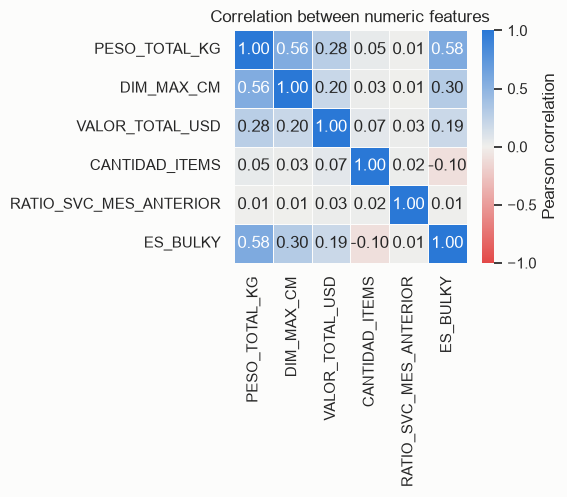

In [20]:
numeric_corr_columns = NUMERIC_FEATURES
correlation = clean[numeric_corr_columns].astype(float).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    correlation,
    ax=ax,
    cmap=DIVERGING_CMAP,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="#fcfcfb",
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlation between numeric features")
fig.tight_layout()

## 5. Group-aware train / validation / test split

Splitting by row would let the same shipment appear on both sides of a split
(fact 9), which would leak information across the split through shared
item-level attributes. `GroupShuffleSplit` on `SHIPMENT_ID` guarantees a
shipment lands entirely on one side. The split is done in two steps to reach
roughly 70/15/15: first carve out test (15%), then split the remainder into
train/validation.

In [21]:
splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(splitter_test.split(clean, groups=clean[GROUP]))
train_val, test = clean.iloc[train_val_idx], clean.iloc[test_idx]

# val should be ~15% of the ORIGINAL total, i.e. ~0.15 / 0.85 of the remainder.
splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter_val.split(train_val, groups=train_val[GROUP]))
train, val = train_val.iloc[train_idx], train_val.iloc[val_idx]

train_groups, val_groups, test_groups = set(train[GROUP]), set(val[GROUP]), set(test[GROUP])
assert not (train_groups & val_groups)
assert not (train_groups & test_groups)
assert not (val_groups & test_groups)

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: {len(part):,} rows, {part[GROUP].nunique():,} shipments, positive rate = {part[LABEL].mean():.3f}")

train = train.drop(columns=GROUP)
val = val.drop(columns=GROUP)
test = test.drop(columns=GROUP)

train: 126,027 rows, 114,775 shipments, positive rate = 0.341
val: 26,945 rows, 24,595 shipments, positive rate = 0.344
test: 27,018 rows, 24,595 shipments, positive rate = 0.343


## 6. Training

`TabularPredictor` is AutoGluon's AutoML entry point: by default it trains
and ensembles several model families (gradient-boosted trees, random
forests, neural networks, ...). The goal here is specifically a neural
network ("RNA"), so `hyperparameters` is restricted to AutoGluon's two
neural-network backends, `NN_TORCH` (PyTorch tabular MLP) and `FASTAI`
(fastai tabular learner) -- no trees are trained.

`eval_metric="average_precision"` instead of accuracy: the label is
imbalanced (~24% positive after cleaning), so a model that always predicts
"not lost" would already score around 76% accuracy while being useless.
Average precision (area under the precision-recall curve) rewards ranking
the positive class well, which is what actually matters for a risk score.

`tuning_data=val` passes the group-aware validation split explicitly,
instead of letting AutoGluon carve its own internal holdout out of `train`
-- an internal holdout would split by row, not by `SHIPMENT_ID`, which would
reintroduce the leak that section 5 was built to avoid.

In [22]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(
    label=LABEL,
    problem_type="binary",
    eval_metric="average_precision",
    path=MODEL_DIR,
).fit(
    train,
    tuning_data=val,
    hyperparameters={"NN_TORCH": {}, "FASTAI": {}},
    time_limit=TIME_LIMIT,
)

Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.12.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.6.0: Fri Jul 31 19:19:08 PDT 2026; root:xnu-12377.161.14~5/RELEASE_ARM64_T6050
CPU Count:          15
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       21.94 GB / 48.00 GB (45.7%)
Disk Space Avail:   747.65 GB / 926.30 GB (80.7%)


No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : Use this if you have a GPU. The go-to preset for best results, and the one to use for benchmark comparisons. New in v1.6: far better than 'best' on datasets <100000 samples by using Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: Nori, TabICLv2, and TabDPT-Turbo. Every model is free for commercial use. Requires `pip install autogluon.tabular[tabarena]`.
	presets='noncommercial': New in v1.6: 'extreme' plus TabPFN-3, a frontier tabular foundation model created by Prior Labs. Stronger still, but commercial use requires a TabPFN-3 license: https://docs.priorlabs.ai/models#tabpfn-model-license
	presets='best'     : Use this if you do not have a GPU. Maximize accuracy. Use in competi

Beginning AutoGluon training ... Time limit = 600s


AutoGluon will save models to "/Users/aristotekean/jave/si/riskship/riskship-rna/AutogluonModels/rna_shipment_loss"


...

	0.7958	 = Validation score   (average_precision)


	0.11s	 = Training   runtime


	0.0s	 = Validation runtime


AutoGluon training complete, total runtime = 84.0s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 214490.6 rows/s (26945 batch size)


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/Users/aristotekean/jave/si/riskship/riskship-rna/AutogluonModels/rna_shipment_loss")


## 7. Evaluation on the held-out test set

`test` was never seen during training or model selection (it was excluded
from both `train` and the `tuning_data` used for early stopping/model
selection), and its shipments are disjoint from both other splits.

In [23]:
predictor.leaderboard(test, display=True)

                 model  score_test  score_val        eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2    0.799453   0.795762  average_precision        0.157321       0.125623  83.701018                 0.000663                0.002236           0.106684            2       True          3
1      NeuralNetFastAI    0.784118   0.778334  average_precision        0.097706       0.064834  53.333558                 0.097706                0.064834          53.333558            1       True          1
2       NeuralNetTorch    0.746954   0.744730  average_precision        0.058952       0.058553  30.260776                 0.058952                0.058553          30.260776            1       True          2


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.799453,0.795762,average_precision,0.157321,0.125623,83.701018,0.000663,0.002236,0.106684,2,True,3
1,NeuralNetFastAI,0.784118,0.778334,average_precision,0.097706,0.064834,53.333558,0.097706,0.064834,53.333558,1,True,1
2,NeuralNetTorch,0.746954,0.744730,average_precision,0.058952,0.058553,30.260776,0.058952,0.058553,30.260776,1,True,2


In [24]:
predictor.evaluate(test, silent=True)

{'average_precision': 0.7994529841789602,
 'accuracy': 0.8091642608631283,
 'balanced_accuracy': np.float64(0.7484042813619509),
 'mcc': 0.5618899202700554,
 'roc_auc': np.float64(0.8484278700242041),
 'f1': 0.666105426758192,
 'precision': 0.83354943273906,
 'recall': 0.5546807592752373}

In [25]:
proba = predictor.predict_proba(test, as_multiclass=False)
y_true = test[LABEL].to_numpy()

roc_auc = roc_auc_score(y_true, proba)
avg_precision = average_precision_score(y_true, proba)
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average precision: {avg_precision:.4f}")

ROC AUC: 0.8484
Average precision: 0.7995


In [26]:
y_pred = (proba >= 0.5).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["not lost", "lost"]))

[[16719  1027]
 [ 4129  5143]]
              precision    recall  f1-score   support

    not lost       0.80      0.94      0.87     17746
        lost       0.83      0.55      0.67      9272

    accuracy                           0.81     27018
   macro avg       0.82      0.75      0.77     27018
weighted avg       0.81      0.81      0.80     27018



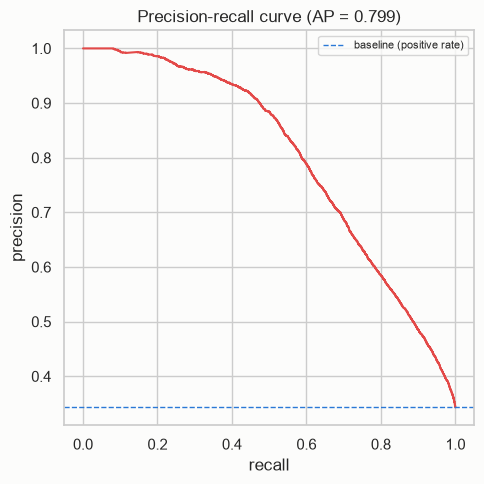

In [27]:
precision, recall, _ = precision_recall_curve(y_true, proba)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recall, precision, color=COLOR_LOST)
ax.axhline(y_true.mean(), color=COLOR_NOT_LOST, linestyle="--", linewidth=1, label="baseline (positive rate)")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title(f"Precision-recall curve (AP = {avg_precision:.3f})")
ax.legend(fontsize=8)
fig.tight_layout()

In [28]:
predictor.feature_importance(test.sample(n=min(5000, len(test)), random_state=RANDOM_STATE), subsample_size=5000, num_shuffle_sets=3)

Computing feature importance via permutation shuffling for 13 features using 5000 rows with 3 shuffle sets...


	1.89s	= Expected runtime (0.63s per shuffle set)


	1.12s	= Actual runtime (Completed 3 of 3 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
DOM_DOMAIN_ID,0.179629,0.005189,0.000139,3,0.209366,0.149893
CANTIDAD_ITEMS,0.128479,0.003445,0.000120,3,0.148218,0.108741
SHP_LG_FACILITY_ID,0.102912,0.002423,0.000092,3,0.116794,0.089030
PESO_TOTAL_KG,0.045889,0.001841,0.000268,3,0.056441,0.035338
ORD_CATEGORY_NAME_L1,0.027603,0.002055,0.000921,3,0.039378,0.015828
PICKING_TYPE,0.017014,0.001875,0.002012,3,0.027758,0.006271
BRAND_NAME,0.015573,0.001442,0.001423,3,0.023836,0.007311
RATIO_SVC_MES_ANTERIOR,0.006745,0.000509,0.000946,3,0.009661,0.003829
day_of_week,0.005769,0.001088,0.005821,3,0.012002,-0.000464
DIM_MAX_CM,0.004237,0.001060,0.010113,3,0.010310,-0.001836


## 8. Limitations and next steps

- The class ratio after cleaning is still a product of which extraction
  window was kept, not a measured real-world prevalence: predicted
  probabilities should be read as a ranking signal, not a calibrated
  real-world loss probability.
- The train/validation/test split is a random group split, not a temporal
  one, so it does not test how the model would perform on genuinely future
  shipments. A time-based split would be a stronger validation of production
  readiness.
- Rows are item-level, not shipment-level; a shipment with many items
  contributes many correlated rows to a split's statistics.
- `preprocess` is written as a single reusable function specifically so it
  can be moved into a standalone inference script without rewriting the
  cleaning logic.
- `LG_REGION` was dropped entirely rather than repaired in this pass. A
  facility -> canonical-region mapping (built independently of the label,
  e.g. from a single trusted source per facility) could recover region as a
  safe feature later; `SHP_LG_FACILITY_ID` already carries the geographic
  signal in the meantime.